[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/moshi4/pyGenomeViz/blob/main/docs/plot_tips.ipynb)

In [1]:
# !pip install pygenomeviz

## Wrapped Labels

Long labels may be easier to read if they are wrapped onto multiple lines.
User can display wrapped labels by applying `⁠textwrap.wrap` to the ⁠*label_handler* argument.

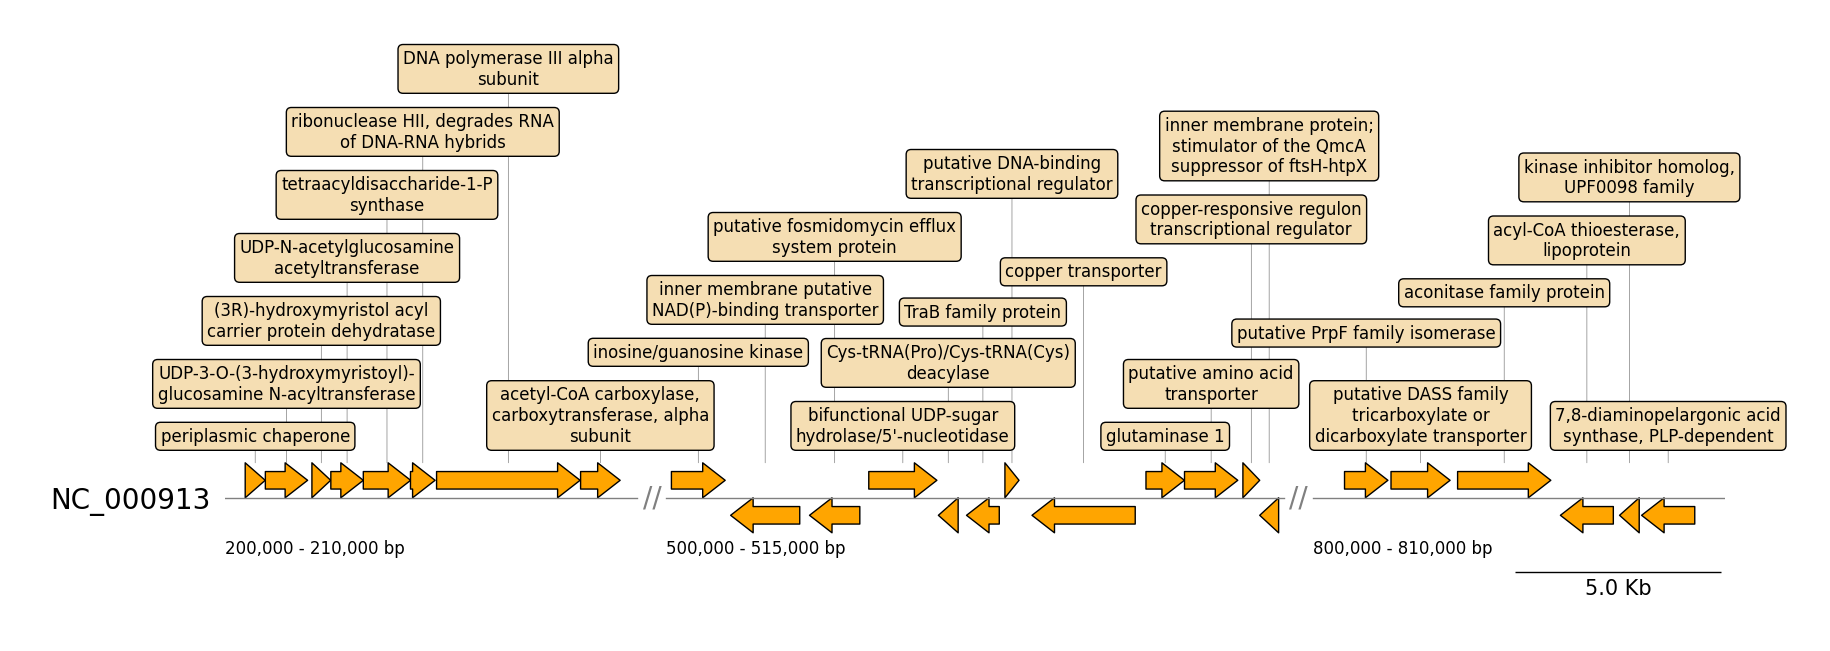

In [2]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset
import textwrap

gbk_files = load_example_genbank_dataset("escherichia_coli")
gbk = Genbank(gbk_files[0])

gv = GenomeViz(fig_track_height=0.7)
gv.set_scale_bar(ymargin=0.5)

target_ranges = ((200000, 210000), (500000, 515000), (800000, 810000))
track = gv.add_feature_track(name=gbk.name, segments=target_ranges)
track.set_segment_sep()

for segment in track.segments:
    segment.add_sublabel()
    # Plot CDS features with gene annotation label
    cds_features = gbk.extract_features(feature_type="CDS", target_range=segment.range)
    segment.add_features(
        cds_features,
        label_type="product",
        annotation=True,
        label_handler=lambda v: "\n".join(textwrap.wrap(v, width=30)),
        lw=1.0,
        text_kws=dict(bbox=dict(boxstyle="round", fc="wheat")),
    )

fig = gv.plotfig()

## Dark Theme

pyGenomeviz supports light(default) or dark themes. The dark theme is displayed as follows.

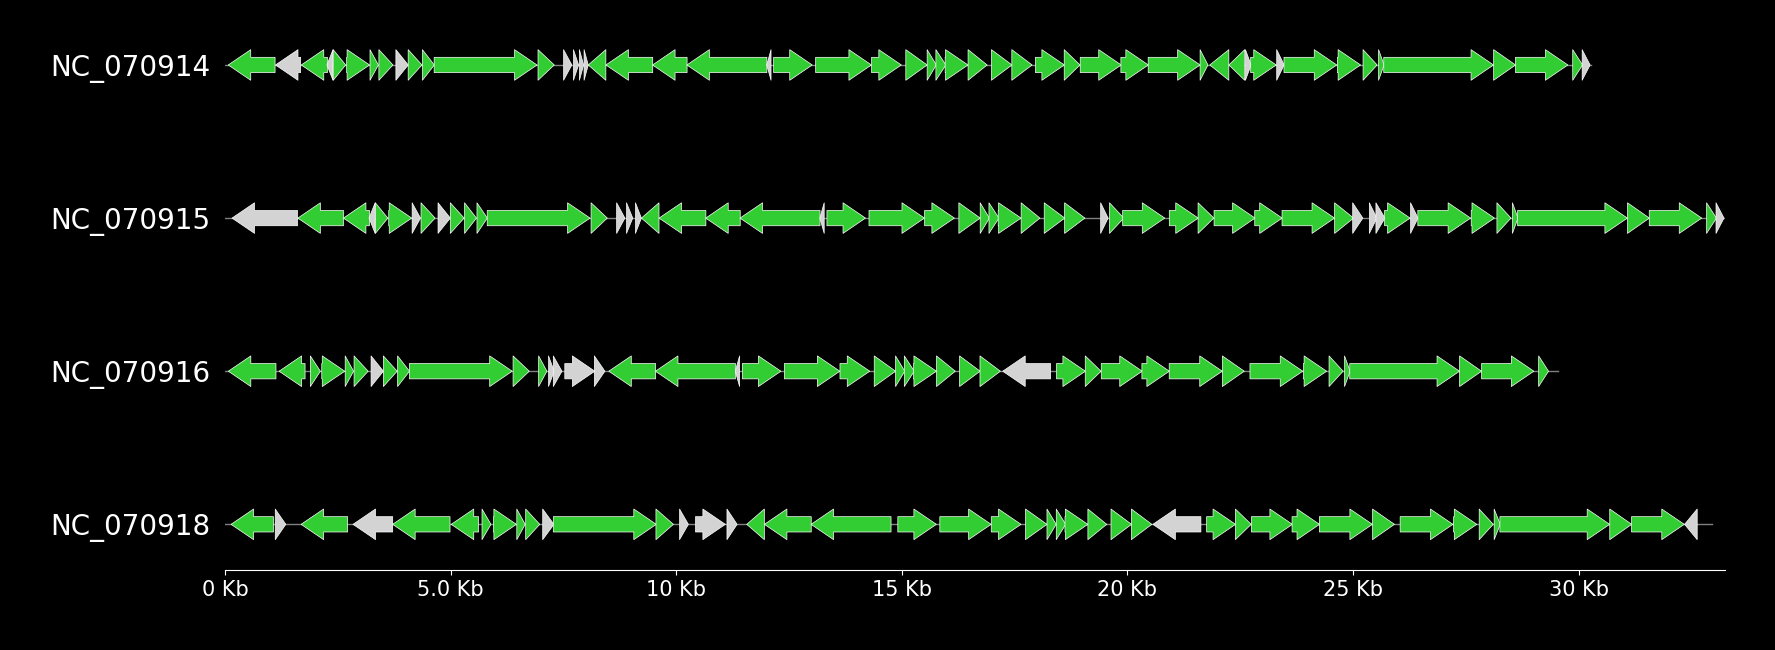

In [3]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset

gbk_files = load_example_genbank_dataset("yersinia_phage")
gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(fig_track_height=0.7, theme="dark") # Set dark theme
gv.set_scale_xticks()

for gbk in gbk_list:
    track = gv.add_feature_track(gbk.name, gbk.genome_length)

    # Plot genbank features
    features = gbk.extract_features()
    for feature in features:
        # Set user-defined feature color based on product name
        product = str(feature.qualifiers.get("product", [""])[0])
        color = "lightgrey" if product.startswith("hypothetical") else "limegreen"
        track.add_features(feature, plotstyle="bigarrow", fc=color, lw=0.5)

fig = gv.plotfig()

## Track Ratio

User can freely change the size ratio of each track.

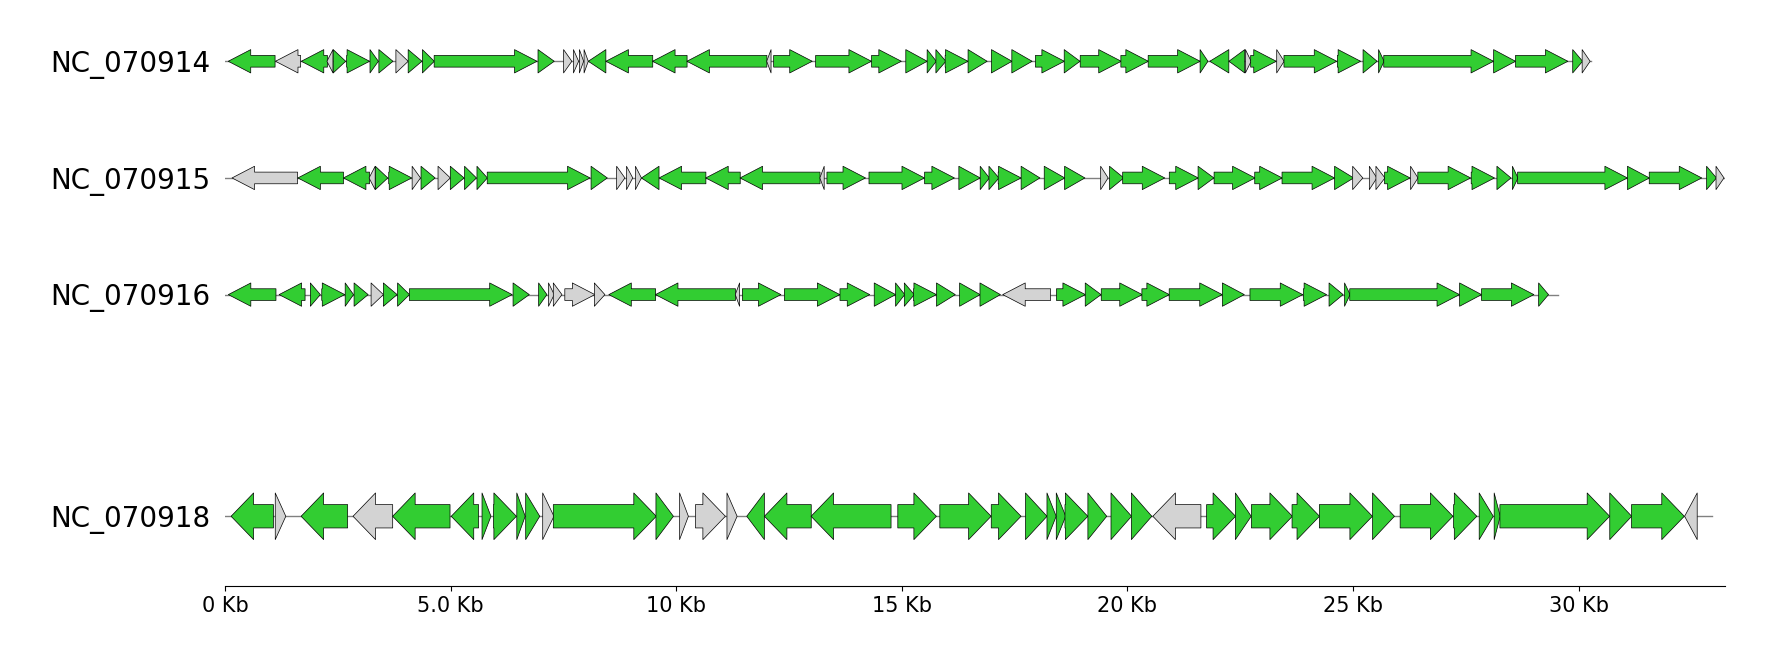

In [4]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset

gbk_files = load_example_genbank_dataset("yersinia_phage")
gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(fig_track_height=0.7)
gv.set_scale_xticks()

for gbk in gbk_list:
    track = gv.add_feature_track(gbk.name, gbk.genome_length)

    # Plot genbank features
    features = gbk.extract_features()
    for feature in features:
        # Set user-defined feature color based on product name
        product = str(feature.qualifiers.get("product", [""])[0])
        color = "lightgrey" if product.startswith("hypothetical") else "limegreen"
        track.add_features(feature, plotstyle="bigarrow", fc=color, lw=0.5)

# Change the ratio of the last feature track and last link track to double.
# Link track indicates track between feature tracks
gv.feature_tracks[-1].set_ratio(0.5) # feature track default ratio = 0.25
gv.link_tracks[-1].set_ratio(2.0) # link track default ratio = 1.0

fig = gv.plotfig()

## Subtrack

Users can add subtracks to a FeatureTrack and plot user-defined graphs to matplotlib Axes of the subtracks
(Option for users familiar with matplotlib)

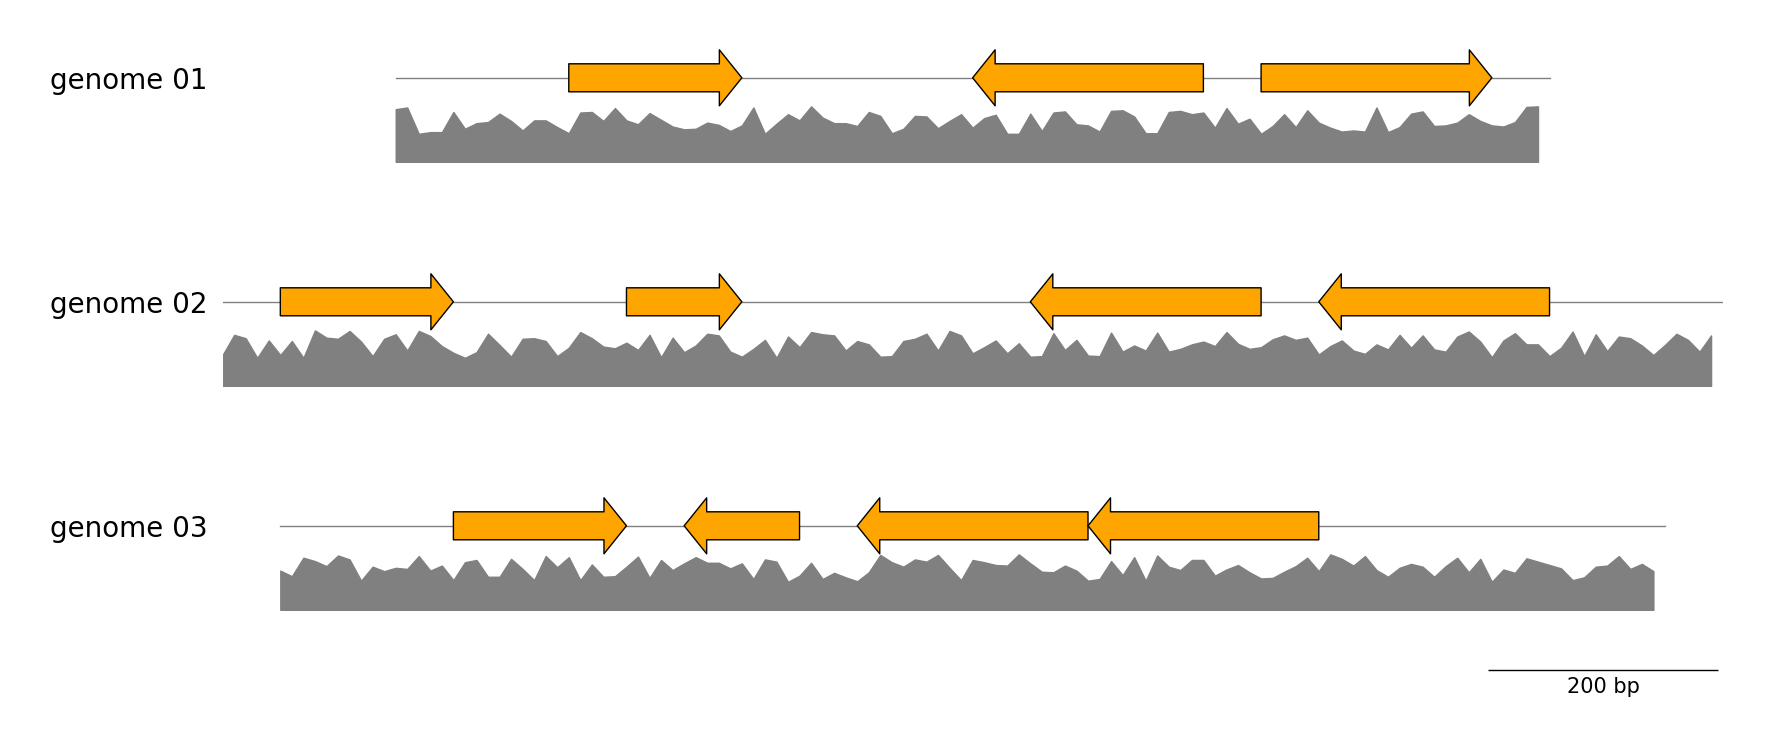

In [5]:
from pygenomeviz import GenomeViz
import numpy as np
np.random.seed(0)

genome_list = [
    ("genome 01", 1000, [(150, 300, 1), (500, 700, -1), (750, 950, 1)]),
    ("genome 02", 1300, [(50, 200, 1), (350, 450, 1), (700, 900, -1), (950, 1150, -1)]),
    ("genome 03", 1200, [(150, 300, 1), (350, 450, -1), (500, 700, -1), (700, 900, -1)]),
]

gv = GenomeViz(fig_track_height=0.7, feature_track_ratio=0.5, track_align_type="center")
gv.set_scale_bar()

for genome in genome_list:
    name, size, features = genome[0], genome[1], genome[2]
    track = gv.add_feature_track(name, size)
    track.add_subtrack(ylim=(0, 100)) # Add subtrack
    for _, feature in enumerate(features, 1):
        start, end, strand = feature
        track.add_feature(start, end, strand, plotstyle="bigarrow", lw=1)

fig = gv.plotfig()

# Plot user-defined graph to subtrack axes
for track in gv.feature_tracks:
    subtrack = track.get_subtrack()
    for segment in track.segments:
        # Plot y = (50 - 100) random values to subtrack
        # Tranform segment-level x coordinate to track-level coordinate
        x = np.arange(segment.start, segment.end, 10)
        x = segment.transform_coord(x)
        y = np.random.randint(50, 100, len(x))
        subtrack.ax.fill_between(x, y, color="grey")

# fig.savefig("result.png")

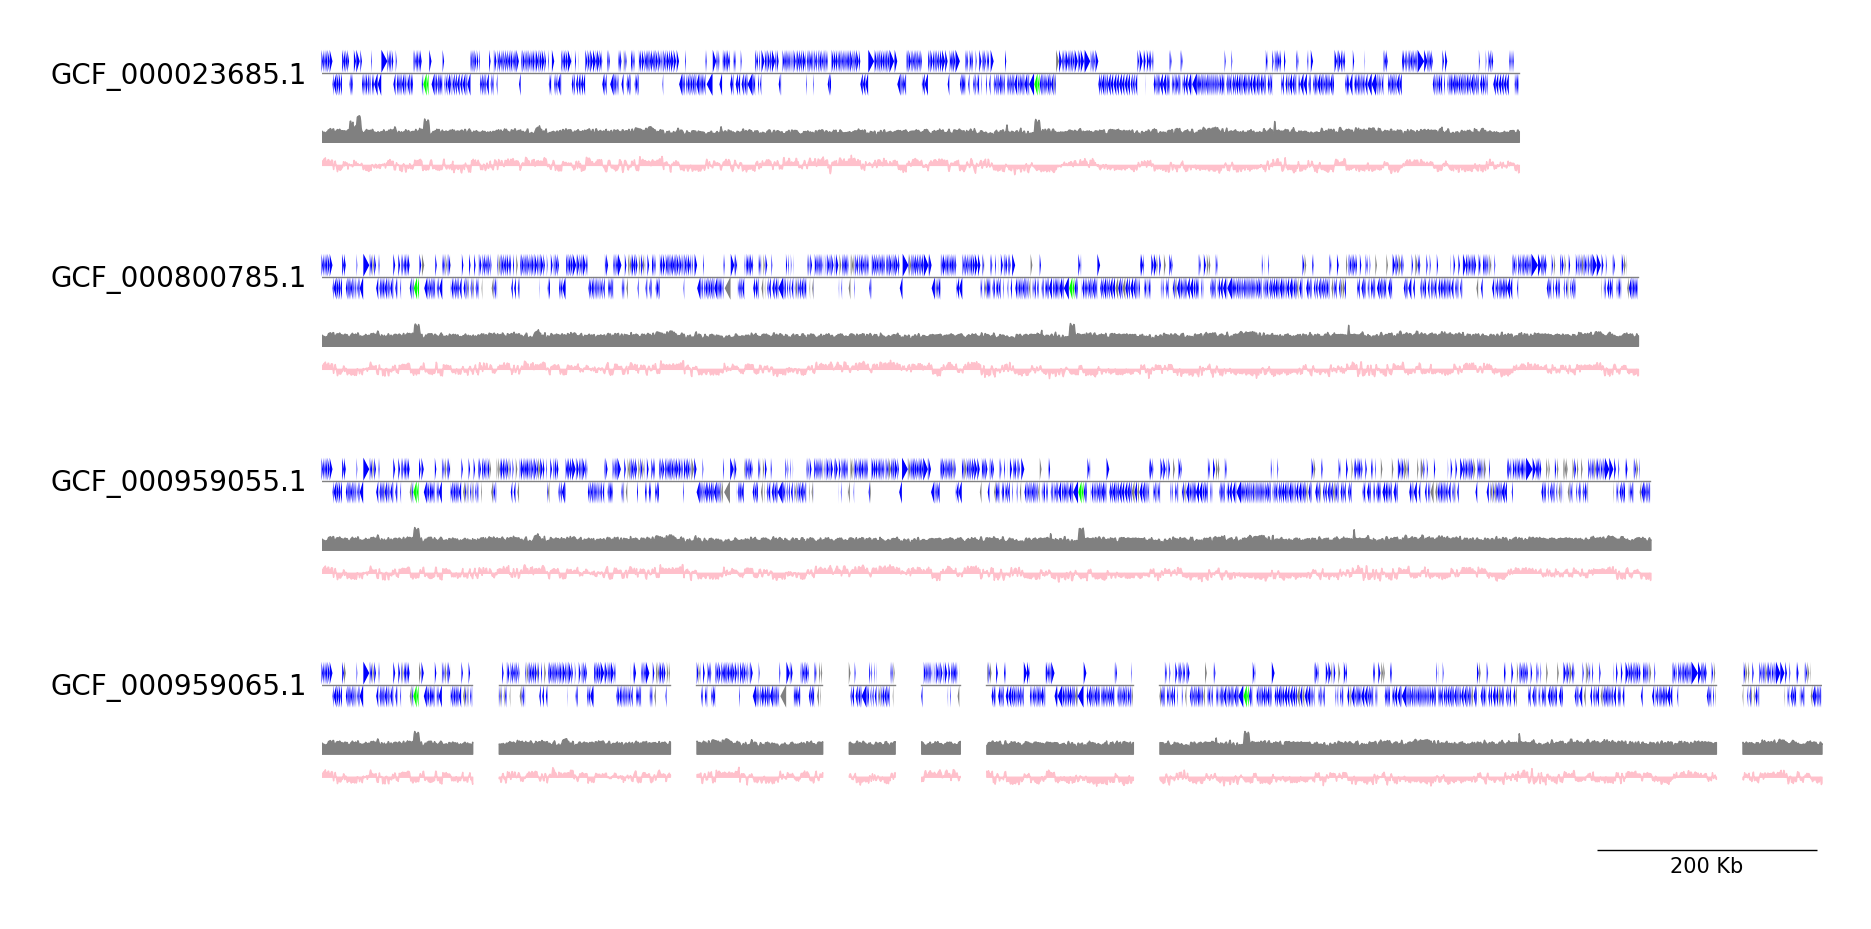

In [6]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset, is_pseudo_feature

gbk_files = load_example_genbank_dataset("mycoplasma_mycoides")
gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(fig_track_height=0.5, feature_track_ratio=0.7)
gv.set_scale_bar()

# Plot CDS, rRNA features for each contig to tracks
for gbk in gbk_list:
    track = gv.add_feature_track(gbk.name, gbk.get_seqid2size(), align_label=False)
    # Add two subtracks
    track.add_subtrack(name="GCcontent", ylim=(0, 100))
    track.add_subtrack(name="GCskew", ylim=(-1, 1))
    for seqid, features in gbk.get_seqid2features(None).items():
        segment = track.get_segment(seqid)
        for feature in features:
            if feature.type == "CDS":
                color = "grey" if is_pseudo_feature(feature) else "blue"
                segment.add_features(feature, fc=color)
            elif feature.type == "rRNA":
                segment.add_features(feature, fc="lime")

fig = gv.plotfig()

# Plot GC content & GC skew graph to subtrack axes
for track, gbk in zip(gv.feature_tracks, gbk_list, strict=True):
    gc_content_subtrack = track.get_subtrack("GCcontent")
    gc_skew_subtrack = track.get_subtrack("GCskew")
    for segment in track.segments:
        seq = gbk.get_seqid2seq()[segment.name]
        # Plot GC content
        x, gc_content = gbk.calc_gc_content(window_size=1000, step_size=500, seq=seq)
        x = segment.transform_coord(x)
        gc_content_subtrack.ax.fill_between(x, gc_content, color="grey")
        # Plot GC skew
        x, gc_skew = gbk.calc_gc_skew(window_size=1000, step_size=500, seq=seq)
        x = segment.transform_coord(x)
        gc_skew_subtrack.ax.fill_between(x, gc_skew, color="pink")

# fig.savefig("result.png")

## Legend

Example of manual legend plotting code using [`Figure.legend()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.legend.html#matplotlib.figure.Figure.legend) method.  
See [Legend guide](https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html) for more details.

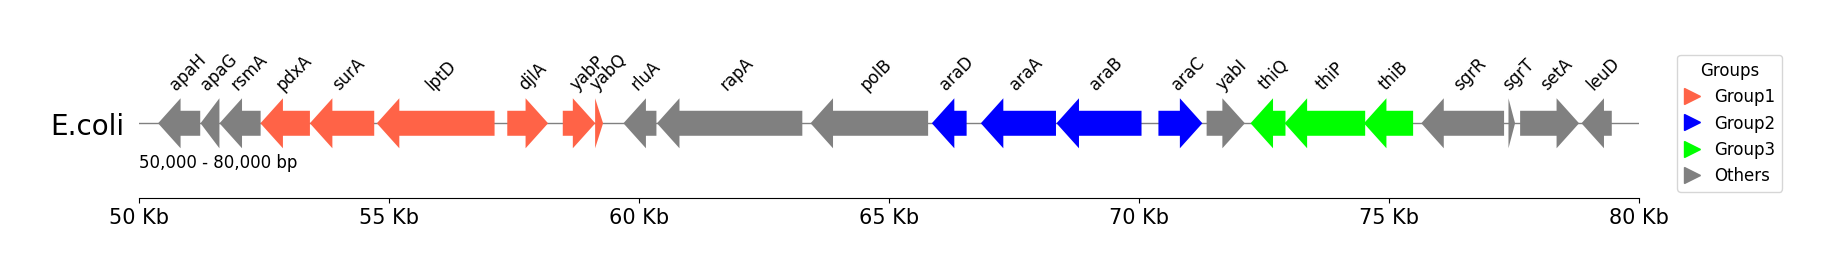

In [7]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Gff
from pygenomeviz.utils import load_example_gff_file
from matplotlib.lines import Line2D

gff_file = load_example_gff_file("escherichia_coli.gff.gz")
gff = Gff(gff_file)

gv = GenomeViz(fig_track_height=0.5)
gv.set_scale_xticks(start=50000)

track = gv.add_feature_track(name="E.coli", segments=(50000, 80000))
track.add_sublabel()

segment = track.get_segment()
for feature in gff.extract_features("CDS", target_range=segment.range):
    # Get gene name in GFF attributes column (e.g. `gene=araD;`)
    gene_name = str(feature.qualifiers.get("gene", [""])[0])
    # Set user-defined feature color based on gene name
    if gene_name.startswith("ara"):
        color = "blue"
    elif gene_name.startswith("thi"):
        color = "lime"
    elif gene_name in ("pdxA", "surA", "lptD", "djlA", "yabP", "yabQ"):
        color = "tomato"
    else:
        color = "grey"
    segment.add_features(feature, plotstyle="bigarrow", color=color, label_type="gene")

fig = gv.plotfig()

# Plot legend for groups
_ = fig.legend(
    handles=[
        Line2D([], [], marker=">", color="tomato", label="Group1", ms=12, ls="none"),
        Line2D([], [], marker=">", color="blue", label="Group2", ms=12, ls="none"),
        Line2D([], [], marker=">", color="lime", label="Group3", ms=12, ls="none"),
        Line2D([], [], marker=">", color="grey", label="Others", ms=12, ls="none"),
    ],
    fontsize=12,
    title="Groups",
    title_fontsize=12,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    handlelength=1.0,
)
# fig.savefig("result.png")

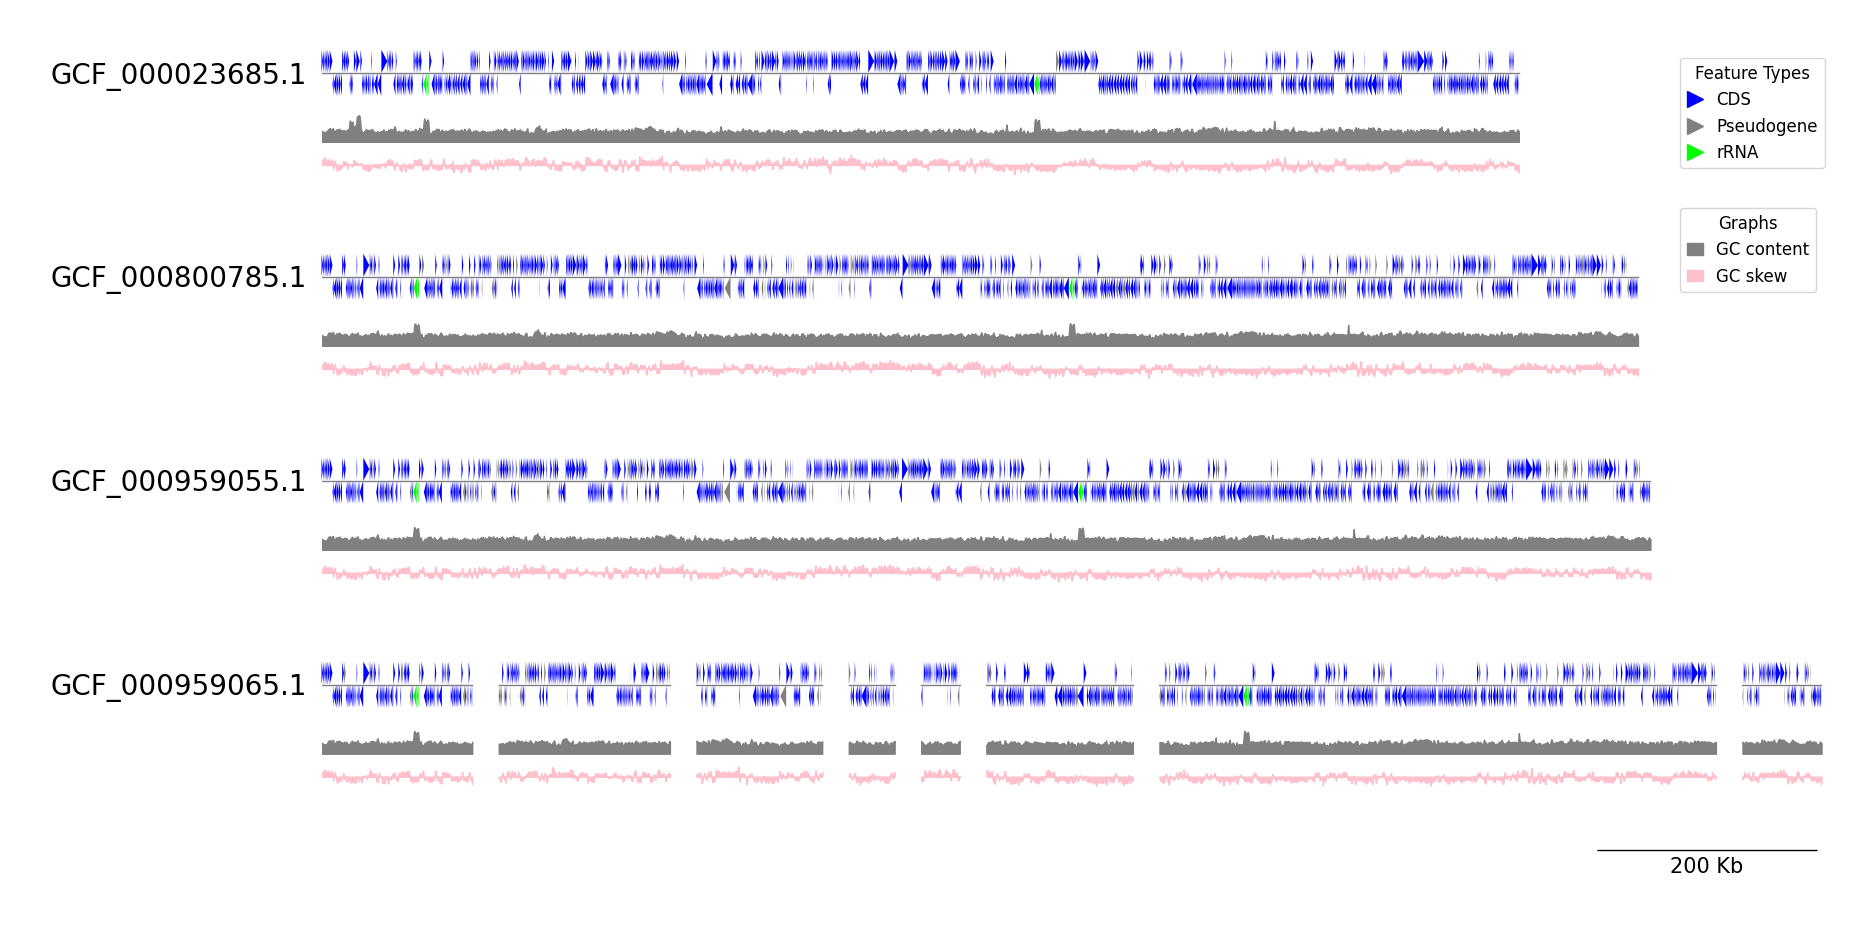

In [8]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset, is_pseudo_feature
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

gbk_files = load_example_genbank_dataset("mycoplasma_mycoides")
gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(fig_track_height=0.5, feature_track_ratio=0.7)
gv.set_scale_bar()

# Plot CDS, rRNA features for each contig to tracks
for gbk in gbk_list:
    track = gv.add_feature_track(gbk.name, gbk.get_seqid2size(), align_label=False)
    # Add two subtracks
    track.add_subtrack(name="GCcontent", ylim=(0, 100))
    track.add_subtrack(name="GCskew", ylim=(-1, 1))
    for seqid, features in gbk.get_seqid2features(None).items():
        segment = track.get_segment(seqid)
        for feature in features:
            if feature.type == "CDS":
                color = "grey" if is_pseudo_feature(feature) else "blue"
                segment.add_features(feature, fc=color)
            elif feature.type == "rRNA":
                segment.add_features(feature, fc="lime")

fig = gv.plotfig()

# Plot GC content & GC skew graph to subtrack axes
for track, gbk in zip(gv.feature_tracks, gbk_list):
    gc_content_subtrack = track.get_subtrack("GCcontent")
    gc_skew_subtrack = track.get_subtrack("GCskew")
    for segment in track.segments:
        seq = gbk.get_seqid2seq()[segment.name]
        # Plot GCcontent
        x, gc_content = gbk.calc_gc_content(window_size=1000, step_size=500, seq=seq)
        x = segment.transform_coord(x)
        gc_content_subtrack.ax.fill_between(x, gc_content, color="grey")
        # Plot GCskew
        x, gc_skew = gbk.calc_gc_skew(window_size=1000, step_size=500, seq=seq)
        x = segment.transform_coord(x)
        gc_skew_subtrack.ax.fill_between(x, gc_skew, color="pink")

# Plot legend for feature types
_ = fig.legend(
    handles=[
        Line2D([], [], marker=">", color="blue", label="CDS", ms=12, ls="none"),
        Line2D([], [], marker=">", color="grey", label="Pseudogene", ms=12, ls="none"),
        Line2D([], [], marker=">", color="lime", label="rRNA", ms=12, ls="none"),
    ],
    fontsize=12,
    title="Feature Types",
    title_fontsize=12,
    bbox_to_anchor=(0.9, 1.0),
    loc="upper left",
    handlelength=1.0,
)

# Plot legend for subtrack graphs
_ = fig.legend(
    handles=[
        Patch(color="grey", label="GC content"),
        Patch(color="pink", label="GC skew"),
    ],
    fontsize=12,
    title="Graphs",
    title_fontsize=12,
    bbox_to_anchor=(0.9, 0.8),
    loc="upper left",
    handlelength=1.0,
)
# fig.savefig("result.png")